In [1]:
from IPython.display import Image

## 5. 기하 변환 

### 0)  학습 목표 

- 동차좌표 동차행렬 
- 영상의 기하변환 종류 
- 영상의 기하변환 방법 (보간)

### 1) 동차좌표 동차핼렬 

 - 수학시간에 주로 사용한 Cartesian 직각 좌표계
    - 1차:$x$, 2차:$(x, y)$, 3차: $(x, y, z)$  
 - Homogeneous coordinate 는 원소를 하나 추가 
    - 1차: $(kx, k)$, 2차:$(kx, ky, k)$, 3차: $(kx, ky, kz, k)$  
    - 2차원에서 동차좌표 $(3, 2, 1) = (6, 4, 2)$ 와 같음, $k$ 는 비례관계 만 따짐  
    - k = 1인 경우 ($(3, 2, 1)$)를 표준 동차 좌표계라고 함.
 - 동차 좌표계를 사용하는 이유
    - 기하학적인 의미 
       - 카메라 프로젝션 (3D를 2D로)에서, 평면의 하나의 점에 매핑되는 점들은 실제로 3차원상에서는 선위의 점
       - 3차원 상의 sheer (밀림, 뒤틀림) 변환은 선형 변환인데, 2차원상에서는 이동 (Translation) 으로 보임 
       - affine 변환은 (엄격한 의미에서) 선형 변환이 아님. 
            -  선형 변환의 조건:  $f(ax + by) = af(x) + bf(y)$ 
            
    - 계산 상의 이점
       
        - 위 특성을 이용하여 이동을 행렬곱으로 포함이 가능하게 하도록 동차 좌표계를 사용.
    
       $p'  = R p  +  t$   (Cartesian 좌표계에서 따로 표시됨)      
    
       $h'  = H h $   (Homogeneous 좌표계에서 하나의 행렬로 표시됨)      
       
 - 동차 행렬
  
     - 동차 좌표의 선형변환을 표현하는 행렬 
     - 2차원 좌표의 변환은 3x3 행렬이됨  M(3,3) = 1 임 
    
     

### 2) 2차원 기하변환들 

- **주의**: 수학시간에 회전은 CCW (반시계방향), 여기서는 CW (시계방향), But 행렬의 모양은 동일함 (y 축방향이 아래쪽이기 때움)

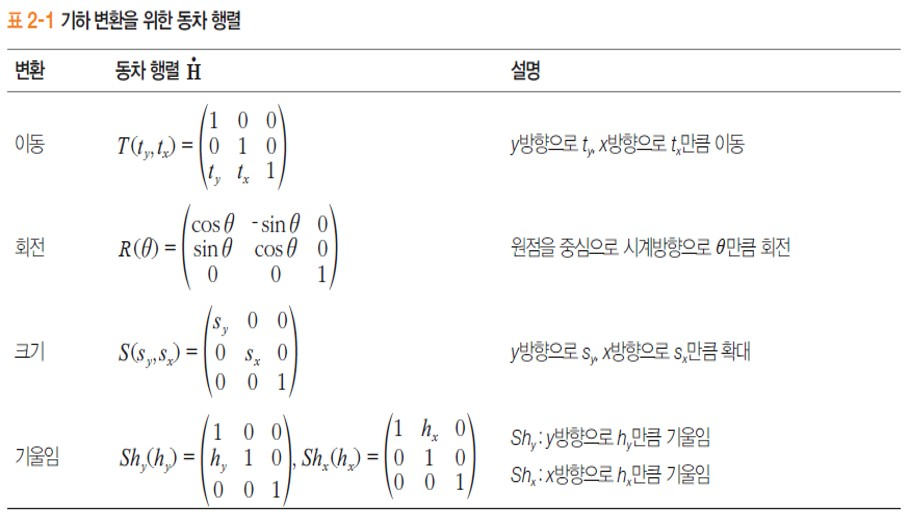

In [2]:
Image("기하변환행렬.jpg", width = 720)

### 2) (선형) 기하 변환

- 입력과 출력의 화소간의 좌표값이 선형관계 
- 비션형 변환인 경우를 포함해서 Warping이라고도 함.

- 선형 변환의 종류 (단계별로 확장, 파라메터 DoF )

   - translation (위치만 이동, 2) 
   - Eucledian   (크기위지하면서 회전과 위치 이동, 3) 
   - similarity  (크기도 변화, 4)
   - affine      (선형 공간 찌그러짐, 평행은 유지되나 각도값은 유지 안됨, 6 )
   - perspective (3차원을 2차원으로 프로젝션, 8)
  

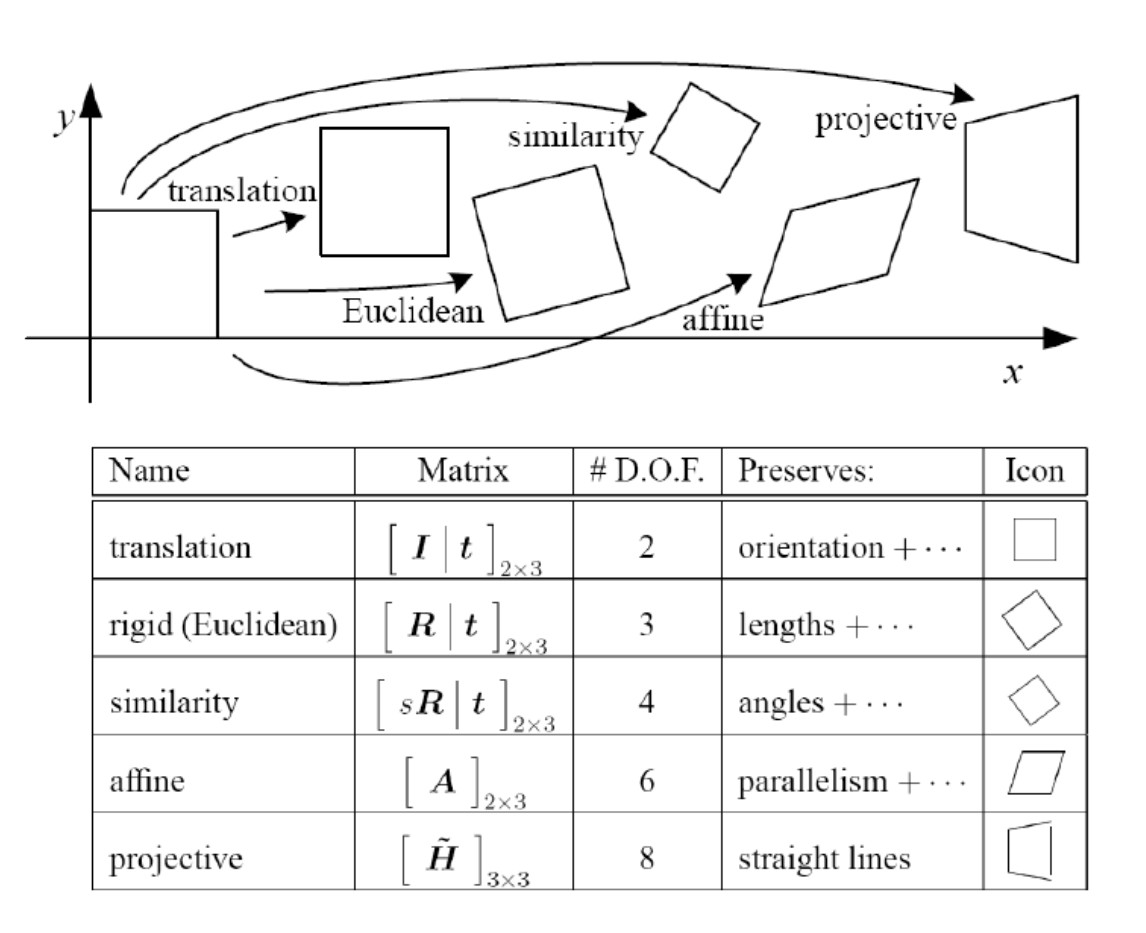

In [3]:
Image("기하변환들.jpg", width = 720)

### 3) 이미지의 기하변환 

#### 전방 (매핑) 변환 

- 입력 좌표 $(y, x)$ 가 변환된 출력 좌표 $ (y', x') = T (y,x)$ 을 이용 하여  $I_out(y, x') = I_{in}(y,x)$ 
- 디지털 영상의 특성으로 Aliasing이 발생 
     - 즉, 출력 측에 비는 좌표 위치나  중복되는 좌표위치 등이 중간에 생김

#### 후방 (매핑) 변환 

- 출력 좌표 $(x', y')$에 영향을 주는 입력 좌표 $ (y, x) = T^{-1} (y',x')$ 을 이용 하여  $I_out(y', x') = I_{in}(y,x)$ 
- Aliasing이 발생  하지 않으나 $(y, x)가 항상 정수값 (정확한 화소 중심)이 아님 
- Interpolation 을 하여 해결
     - 즉, 출력 화소 좌표 (4, 3)에 해당하는 입력 화소 좌표가 (1.2, 3.6) 이라면 (1,3), (1,4), (2,3), (2,4) 4 화소에서 거리를 고려하여 가중치 합을 계산함.
   

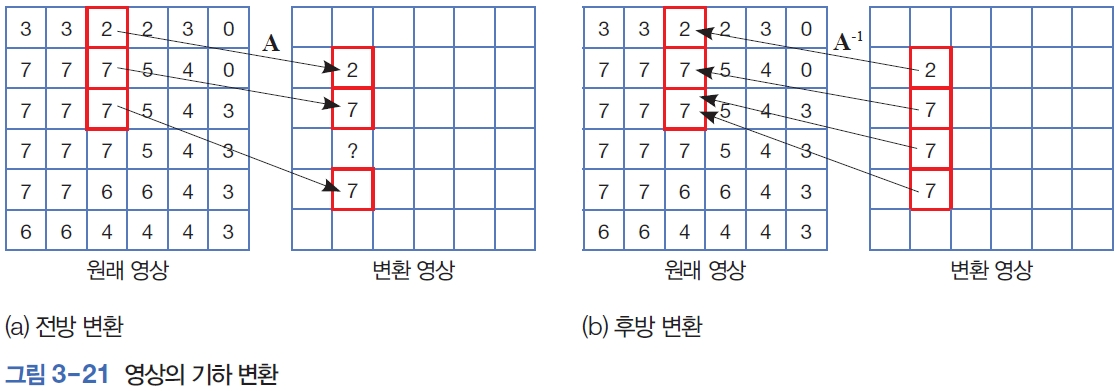

In [4]:
Image("그림 3-21.jpg", width = 720)

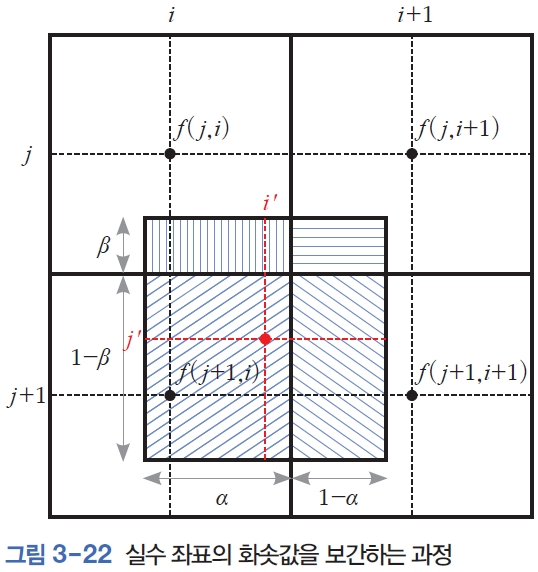

In [5]:
Image("그림 3-22.jpg", width = 360)

### 4) OpenCV 사용한 Affine 변환 실습  

- Affine 변환: Perspective 변환이외의 다른 변환은 affine 변환의 일종
    - Perspective 변환은 3차원 관련 연구에서 사용됨 (진도상 생략하나, 따로 공부하기 바람)
    - Affine 매트릭스 (실제로는 Eucledean matrix)를 만들어 적용함.

(<matplotlib.image.AxesImage at 0x1eb465fbfa0>, Text(0.5, 1.0, 'dst2'))

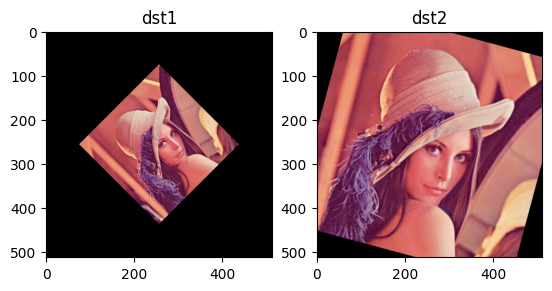

In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

src = cv2.imread('Lena.png')    

rows, cols, channels = src.shape
M1 = cv2.getRotationMatrix2D( (rows/2, cols/2),  45, 0.5 )  # center, rotation, scale 
M2 = cv2.getRotationMatrix2D( (rows/2, cols/2), -15, 1.0 )  # center, rotation, scale 

dst1 = cv2.warpAffine( src, M1, (rows, cols))
dst2 = cv2.warpAffine( src, M2, (rows, cols))

plt.subplot(1,2,1)
plt.imshow(dst1[:,:,::-1]), plt.title('dst1')
plt.subplot(1,2,2)
plt.imshow(dst2[:,:,::-1]), plt.title('dst2')

###  *Matrix 를 자동으로 얻는 방법 (자세한 설명은 나중에)

 -  Affine Matrix 는 미지수가 6개이므로 3개의 매칭점쌍이 정해지면 Matrix 를 수핼 수 있음 (한점당 두개의 식이 나옮) 

(<Axes: title={'center': 'Affine'}>,
 Text(0.5, 1.0, 'Affine'))

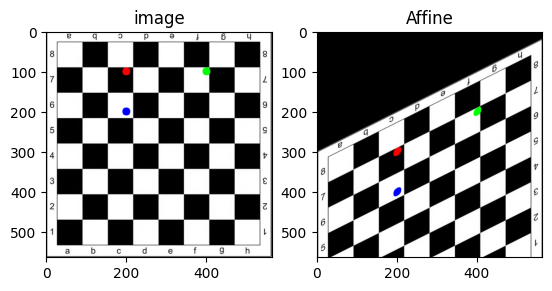

In [7]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
    
img = cv2.imread('chessboard.jpg')
rows, cols, ch = img.shape

pts1 = np.float32([[200,100],[400,100],[200,200]])
pts2 = np.float32([[200,300],[400,200],[200,400]])

# pts1의 좌표에 표시. Affine 변환 후 이동 점 확인.
cv2.circle(img, (200,100), 10, (255,0,0),-1)
cv2.circle(img, (400,100), 10, (0,255,0),-1)
cv2.circle(img, (200,200), 10, (0,0,255),-1)

M = cv2.getAffineTransform(pts1, pts2)

dst = cv2.warpAffine(img, M, (cols,rows))

plt.subplot(121),plt.imshow(img),plt.title('image')
plt.subplot(122),plt.imshow(dst),plt.title('Affine')

### **노트** 위의 Warping은 모두 후방 매핑을 사용한 것임.

###  Alisaing  문제 
  - 단순한 resize 변환에서의 aliasing 문제를 확인 해보기
  - 옵션
      - INTER_NEAREST – a nearest-neighbor interpolation 
      - **INTER_LINEAR** – a bilinear interpolation (used by default) : 가장 흔하게 사용 됨
      - INTER_AREA – resampling using pixel area relation. 
      - INTER_CUBIC – a bicubic interpolation over 4×4 pixel neighborhood 
      - INTER_LANCZOS4 – a Lanczos interpolation over 8×8 pixel neighborhood

Text(0.5, 0.98, 'resize: looks same? see the axis!')

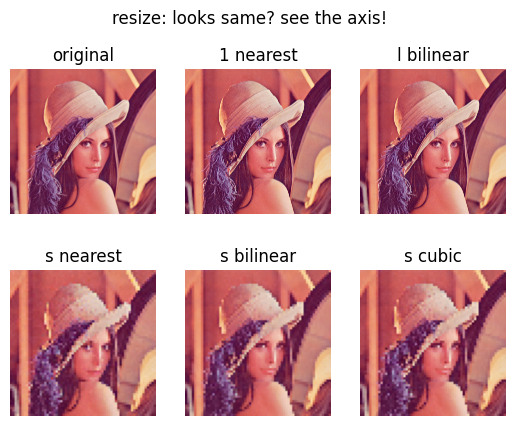

In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('Lena.png')

width = int(img.shape[1]*8 )
height = int(img.shape[0]*8)
dim = (width, height)  # Note:  width-height so shape[1] and shape[0]. ^^;;
img_large_nearest = cv2.resize(img, dim, interpolation = cv2.INTER_NEAREST) 
img_large_bilinear = cv2.resize(img, dim, interpolation = cv2.INTER_LINEAR) 

width = int(img.shape[1]//8 )
height = int(img.shape[0]//8)
dim = (width, height)  # Note:  width-height so shape[1] and shape[0]. ^^;;
img_small_nearest = cv2.resize(img, dim, interpolation = cv2.INTER_NEAREST) 
img_small_bilinear = cv2.resize(img, dim, interpolation = cv2.INTER_LINEAR) 
img_small_cubic = cv2.resize(img, dim, interpolation = cv2.INTER_CUBIC) 

  
plt.subplot(2,3,1),plt.imshow(img[:,:,::-1]),plt.axis('off'),plt.title('original')
plt.subplot(2,3,2),plt.imshow(img_large_nearest[:,:,::-1]), plt.axis('off'),plt.title('1 nearest')
plt.subplot(2,3,3),plt.imshow(img_large_bilinear[:,:,::-1]),plt.axis('off'), plt.title('l bilinear')
plt.subplot(2,3,4),plt.imshow(img_small_nearest[:,:,::-1]),plt.axis('off'),plt.title('s nearest')
plt.subplot(2,3,5),plt.imshow(img_small_bilinear[:,:,::-1]),plt.axis('off'),plt.title('s bilinear')
plt.subplot(2,3,6),plt.imshow(img_small_cubic[:,:,::-1]),plt.axis('off'),plt.title('s cubic')
plt.suptitle('resize: looks same? see the axis!')


### 끝